In [64]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt # For showing plots
import pandas as pd
import seaborn as sns # For plotting
from pathlib import Path

In [98]:
tips_data = sns.load_dataset("tips")

display(tips_data.head())

tips_data.info()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [99]:
tips_data.describe() 

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


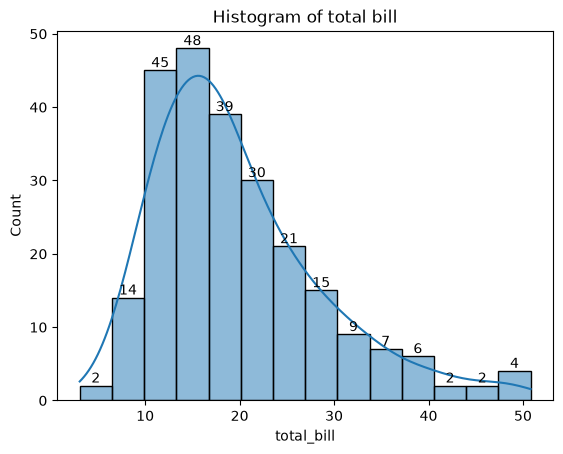

In [100]:
ax = sns.histplot(data=tips_data.total_bill, kde=True)
ax.set_title("Histogram of total bill")

for container in ax.containers:
    ax.bar_label(container)

Text(0.5, 1.0, 'Histogram of tips')

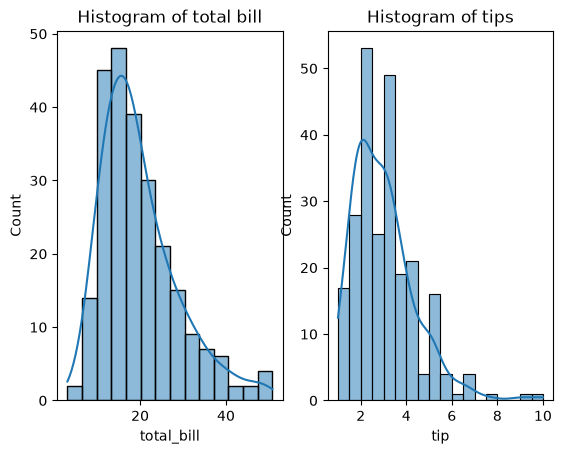

In [101]:
fig, ax = plt.subplots(1, 2)

sns.histplot(data=tips_data.total_bill, kde=True, ax=ax[0])
ax[0].set_title("Histogram of total bill")

sns.histplot(data=tips_data.tip, kde=True, ax=ax[1])
ax[1].set_title("Histogram of tips")

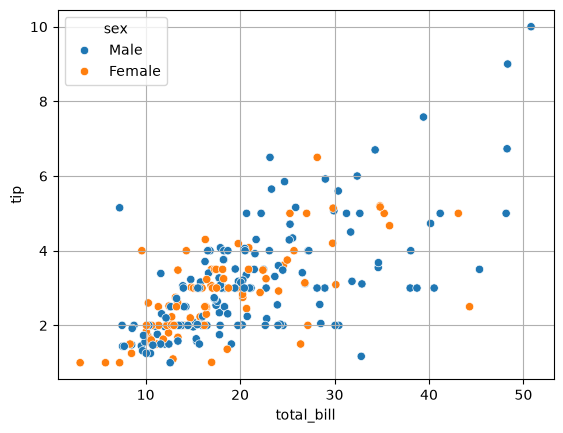

In [102]:
ax = sns.scatterplot(data=tips_data, x="total_bill", y="tip", hue="sex")
ax.grid(True)

<Axes: xlabel='sex', ylabel='Count'>

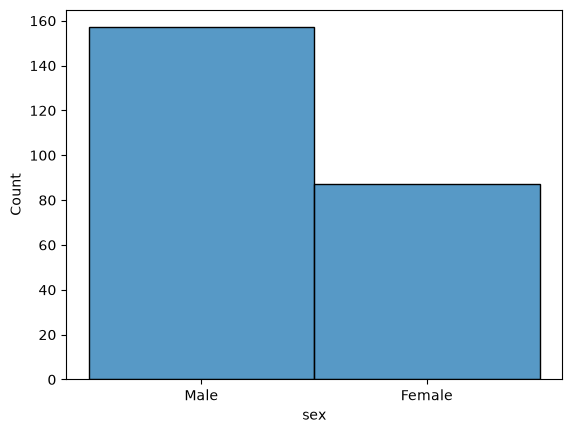

In [103]:
# sns.swarmplot(data=tips_data, x="sex", y="tip", hue="sex")
sns.histplot(data=tips_data, x="sex")

Text(0.5, 1.0, 'box plot of the total bill')

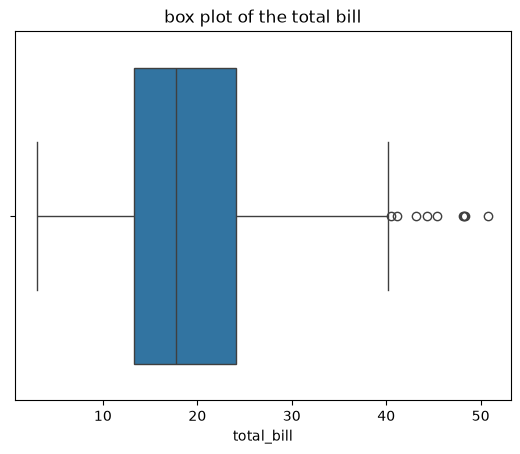

In [104]:
sns.boxplot(x=tips_data.total_bill).set_title("box plot of the total bill")

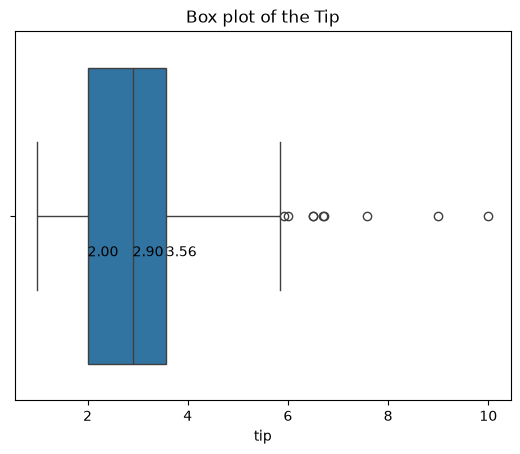

In [105]:
ax = sns.boxplot(x=tips_data["tip"])
ax.set_title("Box plot of the Tip")


q1 = tips_data["tip"].quantile(0.25)
median = tips_data["tip"].median()
q3 = tips_data["tip"].quantile(0.75)

for value in [q1, median, q3]:
    ax.text(value, 0.1, f"{value:.2f}", va="center")

Text(0.5, 1.0, 'box plot for tips for smokers and non-smokers')

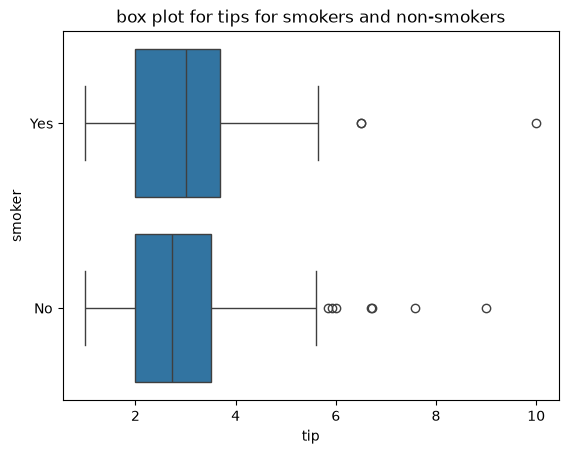

In [106]:
# Creating histograms and boxplots stratified by groups:
sns.boxplot(x=tips_data.tip, y=tips_data.smoker).set_title("box plot for tips for smokers and non-smokers")

In [109]:


# groupby splits the data frame into multiple dataframe containing (group time, group dataframe)
# with each group dataframe containing the observations of that specific time

for (time, df) in tips_data.groupby("time"):
    display(df)

,total_bill,tip,sex,smoker,day,time,size
77,27.20,4.00,Male,No,Thur,Lunch,4
78,22.76,3.00,Male,No,Thur,Lunch,2
79,17.29,2.71,Male,No,Thur,Lunch,2
80,19.44,3.00,Male,Yes,Thur,Lunch,2
81,16.66,3.40,Male,No,Thur,Lunch,2
...,...,...,...,...,...,...,...
222,8.58,1.92,Male,Yes,Fri,Lunch,1
223,15.98,3.00,Female,No,Fri,Lunch,3
224,13.42,1.58,Male,Yes,Fri,Lunch,2
225,16.27,2.50,Female,Yes,Fri,Lunch,2


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


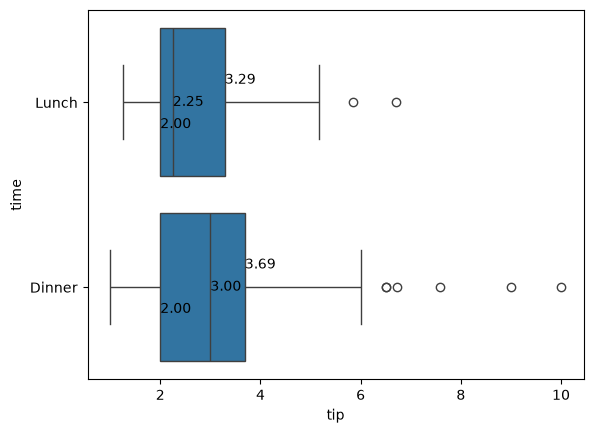

In [111]:
# create a boxplot and a histogram of the tips grouped by time of day
# sns.histplot(data=tips_data, x="tip", hue="time")

fig, ax = plt.subplots()

sns.boxplot(x=tips_data.tip, y=tips_data.time, ax=ax)

for i, (time, group) in enumerate(tips_data.groupby("time")):
    q1 = group["tip"].quantile(0.25)
    median = group["tip"].median()
    q3 = group["tip"].quantile(0.75)

    labels = [
        (q1, 0.12),
        (median, 0),
        (q3, -0.12)
    ]
    for value, offset in labels:
        ax.text(value, i + offset, f"{value:.2f}", va="center")

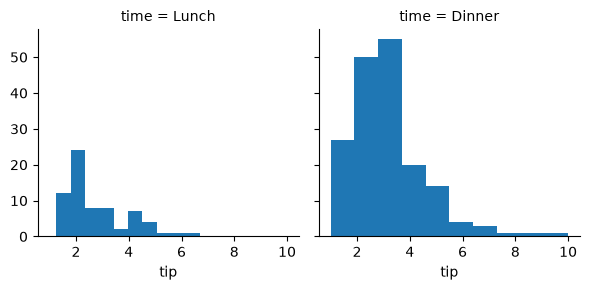

In [119]:
# We can also compare the tip distributions based on whether the tip was paid for lunch or dinner.

g = sns.FacetGrid(data=tips_data, col="time")
g = g.map(plt.hist, "tip")

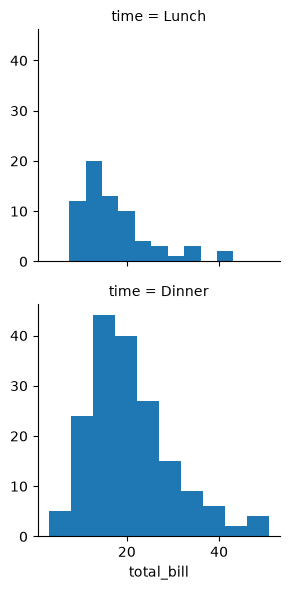

In [120]:
g = sns.FacetGrid(data=tips_data, row="time")
g = g.map(plt.hist, "total_bill")

<Axes: xlabel='tip', ylabel='day'>

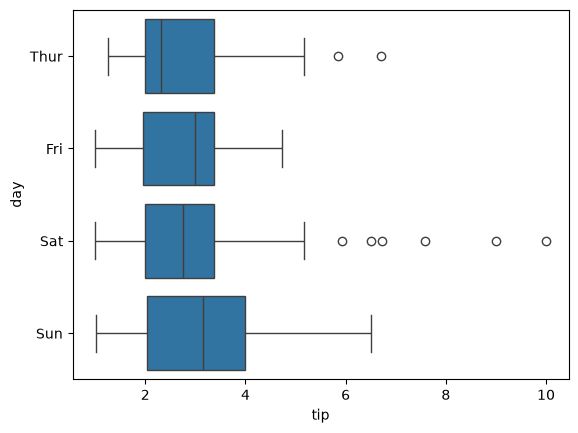

In [126]:
# distribution of tips per day of the week:
sns.boxplot(x=tips_data.tip, y=tips_data.day)

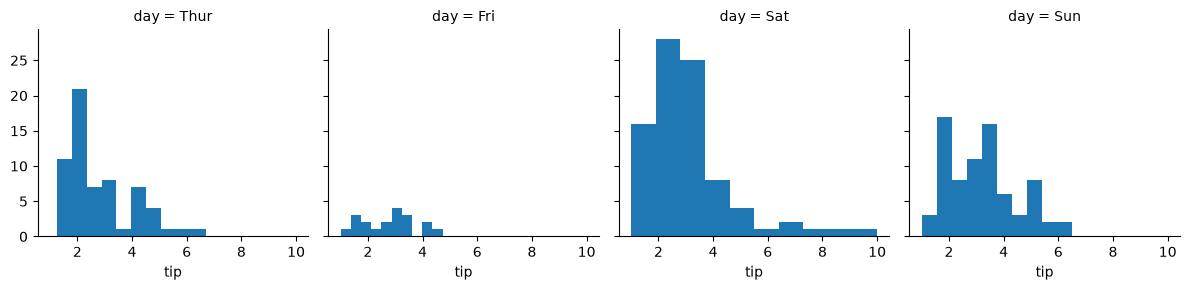

In [129]:
g = sns.FacetGrid(tips_data, col="day")
g.map(plt.hist, "tip")